In [1]:
import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt
from glob import glob

In [2]:
ifiles = glob('data/statistics/bootstrap_chunks_rsq/*.csv')

df = pd.concat([pd.read_csv(ifile) for ifile in ifiles])
df['region'] = 'National'


In [3]:
len(df['model_name'].unique())

23

In [4]:
model_names = {
    'Year + Month': 1,
    'Year|region + Month|region': 2,
    'Climate(lag 1-5)': 3,
    'Climate(lag 1-5) + Year|region': 4,
    'Climate(lag 1-5) + Month|region': 5,
    'Year|region + Month|region + P(Climate)': 6,
    'Year + Month + P(Climate)': 6,
    'Climate(lag 1) + Year|region + Month|region': 7,
    'Climate(lag 1-3) + Year|region + Month|region': 8,
    'Climate(lag 1-5) + Year|region + Month|region': 9,
    'Climate(lag 1-5) + Year|region + Month|region + Socio': 10,
    'Climate(lag 1-5) + Year|region + Month|region + PriorCases': 11,
    'Climate(lag 1-5) + Year|region + Month|region + SeroRepla': 12,
    'Climate(lag 1-5) + Year|region + Month|region + Immunity': 13,
    'Climate(lag 1-5) + Socio': 14,
    'Climate(lag 1-5) + PriorCases': 15,
    'Climate(lag 1-5) + SeroRepla': 16,
    'Climate(lag 1-5) + Immunity': 17,
    'Climate(lag 1-5) + PriorCases + SeroRepla + Socio + Immunity': 18,
    'Month|region + PriorCases + SeroRepla + Socio + Immunity': 19,
    'Year|region + Month|region + PriorCases + SeroRepla + Socio + Immunity': 20,        
    'Climate(lag 1-5) + Year|region + Month|region + PriorCases + SeroRepla + Socio + Immunity': 21,    
    'Climate(lag 1-5) + PriorCases + SeroRepla + Socio': 22,
    'Climate(lag 1-5) + Year|region + Month|region + PriorCases + SeroRepla + Socio': 23,
}


model_ids = {
    'Climate(lag 1-5)': 'C15',
    'Climate(lag 1-5) + Month|region': 'C15-Mr',
    'Climate(lag 1-5) + PriorCases': 'C15-c(PC)',
    'Climate(lag 1-5) + SeroRepla': 'C15-c(SR)',
    'Climate(lag 1-5) + Socio': 'C15-c(S)',
    'Climate(lag 1-5) + Immunity': 'C15-c(IM)',
    'Year + Month': 'Y-M',
    'Month|region + PriorCases + SeroRepla + Socio + Immunity': 'Mr-c(PC,SR,S,IM)',
    'Climate(lag 1-5) + PriorCases + SeroRepla + Socio + Immunity': 'C15-c(PC,SR,S,IM)',
    'Year + Month + P(Climate)': 'Y-M-P(C)',
    'Year|region + Month|region + P(Climate)': 'Y-M-P(C)',
    'Climate(lag 1-5) + Year|region': 'C15-Yr',
    'Climate(lag 1) + Year|region + Month|region': 'C1-Yr-Mr',
    'Climate(lag 1-3) + Year|region + Month|region': 'C13-Yr-Mr',
    'Climate(lag 1-5) + Year|region + Month|region': 'C15-Yr-Mr',
    'Climate(lag 1-5) + Year|region + Month|region + SeroRepla': 'C15-Yr-Mr-c(SR)',
    'Climate(lag 1-5) + Year|region + Month|region + Immunity': 'C15-Yr-Mr-c(IM)',
    'Climate(lag 1-5) + Year|region + Month|region + Socio': 'C15-Yr-Mr-c(S)',
    'Climate(lag 1-5) + Year|region + Month|region + PriorCases': 'C15-Yr-Mr-c(PC)',
    'Year|region + Month|region + PriorCases + SeroRepla + Socio + Immunity': 'Yr-Mr-c(PC,SR,S,IM)',
    'Climate(lag 1-5) + Year|region + Month|region + PriorCases + SeroRepla + Socio + Immunity': 'C15-Yr-Mr-c(PC,SR,S,IM)',
    'Climate(lag 1-5) + PriorCases + SeroRepla + Socio': 'C15-c(PC,SR,S)',
    'Climate(lag 1-5) + Year|region + Month|region + PriorCases + SeroRepla + Socio': 'C15-Yr-Mr-c(PC,SR,S)',
}


order = [
    'C15',
    'C15-Mr',
    'C15-c(PC)',
    'C15-c(SR)',
    'C15-c(S)',
    'C15-c(IM)',
    'Y-M',
    'Mr-c(PC,SR,S,IM)',
    'C15-c(PC,SR,S)',
    'C15-c(PC,SR,S,IM)',
    'Y-M-P(C)',
    'C15-Yr',
    'C1-Yr-Mr',
    'C13-Yr-Mr',
    'C15-Yr-Mr',
    'C15-Yr-Mr-c(SR)',
    'C15-Yr-Mr-c(IM)',
    'C15-Yr-Mr-c(S)',
    'C15-Yr-Mr-c(PC)',
    'Yr-Mr-c(PC,SR,S,IM)',
    'C15-Yr-Mr-c(PC,SR,S)',
    'C15-Yr-Mr-c(PC,SR,S,IM)',
]

In [5]:
df['model_order'] = df['model_name'].map(model_names)
df['model_id'] = df['model_name'].map(model_ids)

df_rsq = df.copy().sort_values(['bootstrap_iteration', 'model_order']).reset_index(drop=True)
df_aic = df.copy().sort_values(['bootstrap_iteration', 'model_order']).reset_index(drop=True)
df_prsq = df.copy().sort_values(['bootstrap_iteration', 'model_order']).reset_index(drop=True)

baseline = df_rsq[df_rsq['model_name'] == 'Year|region + Month|region'] \
    .set_index(['bootstrap_iteration', 'region'])['r_squared']
df_rsq['r_squared_normed'] = df_rsq.apply(
    lambda row: 100 * (row['r_squared'] / baseline[(row['bootstrap_iteration'], row['region'])] - 1), axis=1
)
df_rsq = df_rsq[df_rsq['model_name'] != 'Year|region + Month|region']

df_rsq

,r_squared,pseudo_r_squared,aic,n_obs,bootstrap_iteration,model_name,region,model_order,model_id,r_squared_normed
0,0.437067,0.729153,3.923343e+07,1342740,1,Year + Month,National,1,Y-M,-11.132162
2,0.326284,0.673930,4.723122e+07,1342740,1,Climate(lag 1-5),National,3,C15,-33.657525
3,0.547058,0.770932,3.318279e+07,1342740,1,Climate(lag 1-5) + Year|region,National,4,C15-Yr,11.231965
4,0.366868,0.686309,4.543858e+07,1342740,1,Climate(lag 1-5) + Month|region,National,5,C15-Mr,-25.405648
5,0.507208,0.744378,3.702842e+07,1342740,1,Year + Month + P(Climate),National,6,Y-M-P(C),3.129418
...,...,...,...,...,...,...,...,...,...,...
23695,0.689703,0.790535,7.062289e+07,1793688,1000,Year|region + Month|region + PriorCases + Sero...,National,20,"Yr-Mr-c(PC,SR,S,IM)",28.030282
23696,0.690131,0.790488,7.063894e+07,1793688,1000,Year|region + Month|region + PriorCases + Sero...,National,20,"Yr-Mr-c(PC,SR,S,IM)",28.109694
23697,0.777745,0.807026,6.506362e+07,1793688,1000,Climate(lag 1-5) + Year|region + Month|region ...,National,21,"C15-Yr-Mr-c(PC,SR,S,IM)",44.373593
23698,0.754006,0.727743,9.248229e+07,1822968,1000,Climate(lag 1-5) + PriorCases + SeroRepla + Socio,National,22,"C15-c(PC,SR,S)",39.966874


/tmp/ipykernel_5278/1107192809.py:54: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axarr[1].legend(


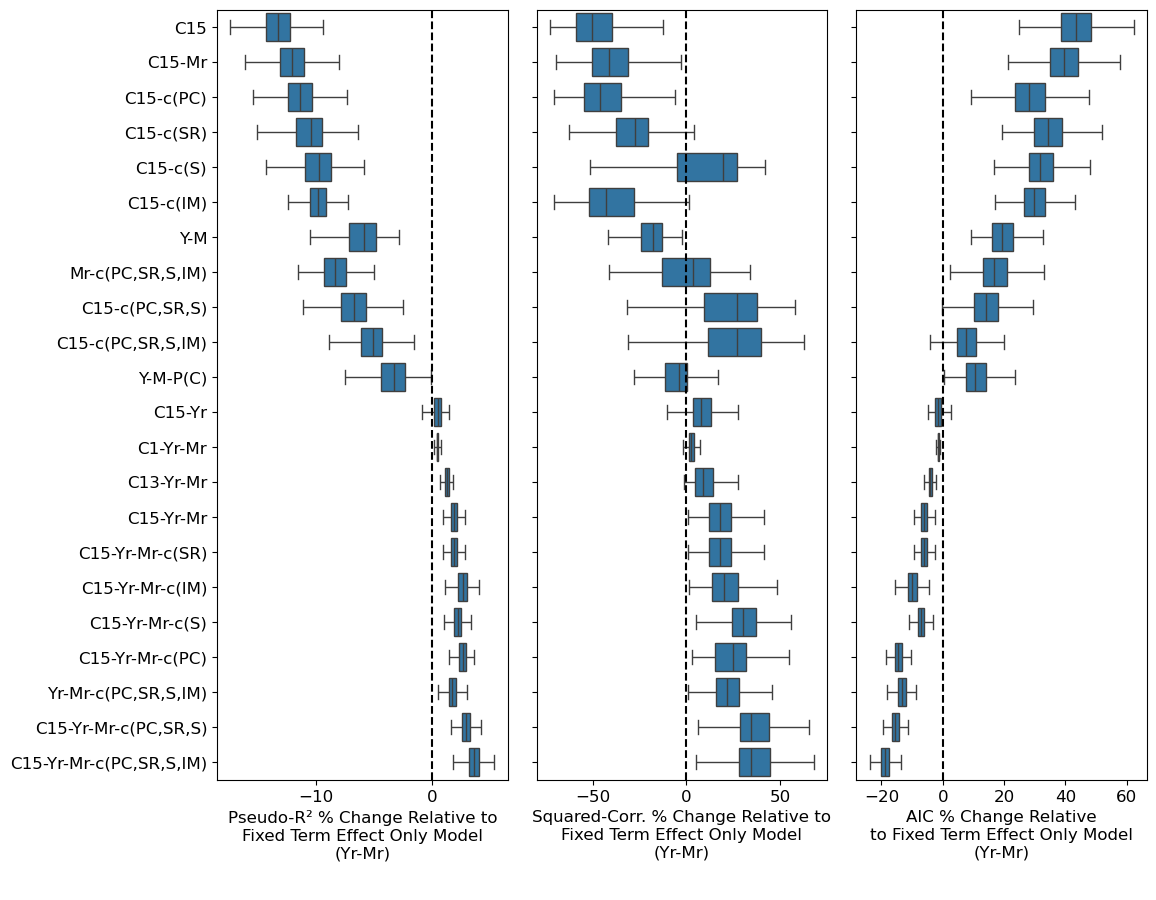

In [6]:
plt.rcParams.update({'font.size': 12})

df['model_order'] = df['model_name'].map(model_names)
df['model_id'] = df['model_name'].map(model_ids)

df_rsq = df.copy().sort_values(['bootstrap_iteration', 'model_order']).reset_index(drop=True)
df_aic = df.copy().sort_values(['bootstrap_iteration', 'model_order']).reset_index(drop=True)
df_prsq = df.copy().sort_values(['bootstrap_iteration', 'model_order']).reset_index(drop=True)

baseline = df_rsq[df_rsq['model_name'] == 'Year|region + Month|region'] \
    .set_index(['bootstrap_iteration', 'region'])['r_squared']
df_rsq['r_squared_normed'] = df_rsq.apply(
    lambda row: 100 * (row['r_squared'] / baseline[(row['bootstrap_iteration'], row['region'])] - 1), axis=1
)
df_rsq = df_rsq[df_rsq['model_name'] != 'Year|region + Month|region']

baseline = df_prsq[df_prsq['model_name'] == 'Year|region + Month|region'] \
    .set_index(['bootstrap_iteration', 'region'])['pseudo_r_squared']
df_prsq['r_squared_normed'] = df_prsq.apply(
    lambda row: 100 * (row['pseudo_r_squared'] / baseline[(row['bootstrap_iteration'], row['region'])] - 1), axis=1
)
df_prsq = df_prsq[df_prsq['model_name'] != 'Year|region + Month|region']

baseline = df_aic[df_aic['model_name'] == 'Year|region + Month|region'] \
    .set_index(['bootstrap_iteration', 'region'])['aic']
df_aic['aic_normed'] = df_aic.apply(
    lambda row: 100 * (row['aic'] / baseline[(row['bootstrap_iteration'], row['region'])] - 1), axis=1
)
df_aic = df_aic[df_aic['model_name'] != 'Year|region + Month|region']

fig, axarr = plt.subplots(1, 3, figsize=(12, 10), gridspec_kw={'wspace': 0.1}, sharey=True)

df_prsq_in = df_prsq.copy()
df_rsq_in = df_rsq.copy()
df_aic_in = df_aic.copy()

df_prsq_in['stat'] = 'In-Sample'
df_rsq_in['stat'] = 'In-Sample'
df_aic_in['stat'] = 'In-Sample'

sns.boxplot(
    y='model_id', x='r_squared_normed', data=df_prsq, ax=axarr[0], 
    order=order, showfliers=False, legend=False
)
sns.boxplot(
    y='model_id', x='r_squared_normed', data=df_rsq, ax=axarr[1], 
    order=order, showfliers=False, legend=True
)
sns.boxplot(
    y='model_id', x='aic_normed', data=df_aic, ax=axarr[2], 
    order=order, showfliers=False, legend=False
)

axarr[1].legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.12),
    frameon=False,
    fontsize=10,
    ncols=3
)


axarr[0].set_ylabel('')
axarr[0].set_xlabel('Pseudo-R² % Change Relative to\nFixed Term Effect Only Model\n(Yr-Mr)')
axarr[1].set_xlabel('Squared-Corr. % Change Relative to\nFixed Term Effect Only Model\n(Yr-Mr)')
axarr[2].set_xlabel('AIC % Change Relative\nto Fixed Term Effect Only Model\n(Yr-Mr)')

axarr[0].axvline(0, color='k', ls='--')
axarr[1].axvline(0, color='k', ls='--')
axarr[2].axvline(0, color='k', ls='--')


In [7]:
ifiles = glob('/gws/ssde/j25a/cpdn_nonnerc/aaim/dengue/outsample-statistics/bootstrap_chunks/validation_model*')

df = pd.concat([pd.read_csv(ifile) for ifile in ifiles])
df['region'] = 'National'

df['r_squared'] = df['correlation'] ** 2
df = df.rename(columns={'pseudo_r2': 'pseudo_r_squared', 'iteration': 'bootstrap_iteration', 'model': 'model_name'})

df['model_order'] = df['model_name'].map(model_names)
df['model_id'] = df['model_name'].map(model_ids)

df

,model_name,bootstrap_iteration,mae,rmse,correlation,pseudo_r_squared,training_years,validation_years,note,region,r_squared,model_order,model_id
0,Year + Month,1,14.783440,106.819850,0.442360,0.529693,2004-2005-2006-2007-2008,2009-2010-2011-2012-2013,Success,National,0.195682,1,Y-M
1,Year + Month,2,15.376993,144.347631,0.470748,0.563588,2002-2003-2004-2005-2006,2007-2008-2009-2010-2011,Success,National,0.221603,1,Y-M
2,Year + Month,3,14.543044,106.428568,0.301837,0.497037,2010-2011-2012-2013-2014,2015-2016-2017-2018-2019,Success,National,0.091105,1,Y-M
3,Year + Month,4,14.403147,120.111792,0.377402,0.500284,2001-2002-2003-2004-2005,2006-2007-2008-2009-2010,Success,National,0.142433,1,Y-M
4,Year + Month,5,16.495768,164.939244,0.312106,0.403360,2005-2006-2007-2008-2009,2010-2011-2012-2013-2014,Success,National,0.097410,1,Y-M
...,...,...,...,...,...,...,...,...,...,...,...,...,...
20,Climate(lag 1-5) + Year|region + Month|region ...,96,26.661265,367.802396,0.555241,0.714973,2006-2007-2008-2009-2010,2011-2012-2013-2014-2015,Success,National,0.308293,23,"C15-Yr-Mr-c(PC,SR,S)"
21,Climate(lag 1-5) + Year|region + Month|region ...,97,27.943942,445.786487,0.493717,0.651179,2006-2007-2008-2009-2010,2011-2012-2013-2014-2015,Success,National,0.243757,23,"C15-Yr-Mr-c(PC,SR,S)"
22,Climate(lag 1-5) + Year|region + Month|region ...,98,194.832878,18515.111333,0.006285,-1.792308,2001-2002-2003-2004-2005,2006-2007-2008-2009-2010,Success,National,0.000040,23,"C15-Yr-Mr-c(PC,SR,S)"
23,Climate(lag 1-5) + Year|region + Month|region ...,99,15.903227,163.231467,0.368395,0.556058,2008-2009-2010-2011-2012,2013-2014-2015-2016-2017,Success,National,0.135715,23,"C15-Yr-Mr-c(PC,SR,S)"


/tmp/ipykernel_5278/3092460677.py:37: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axarr[1].legend(


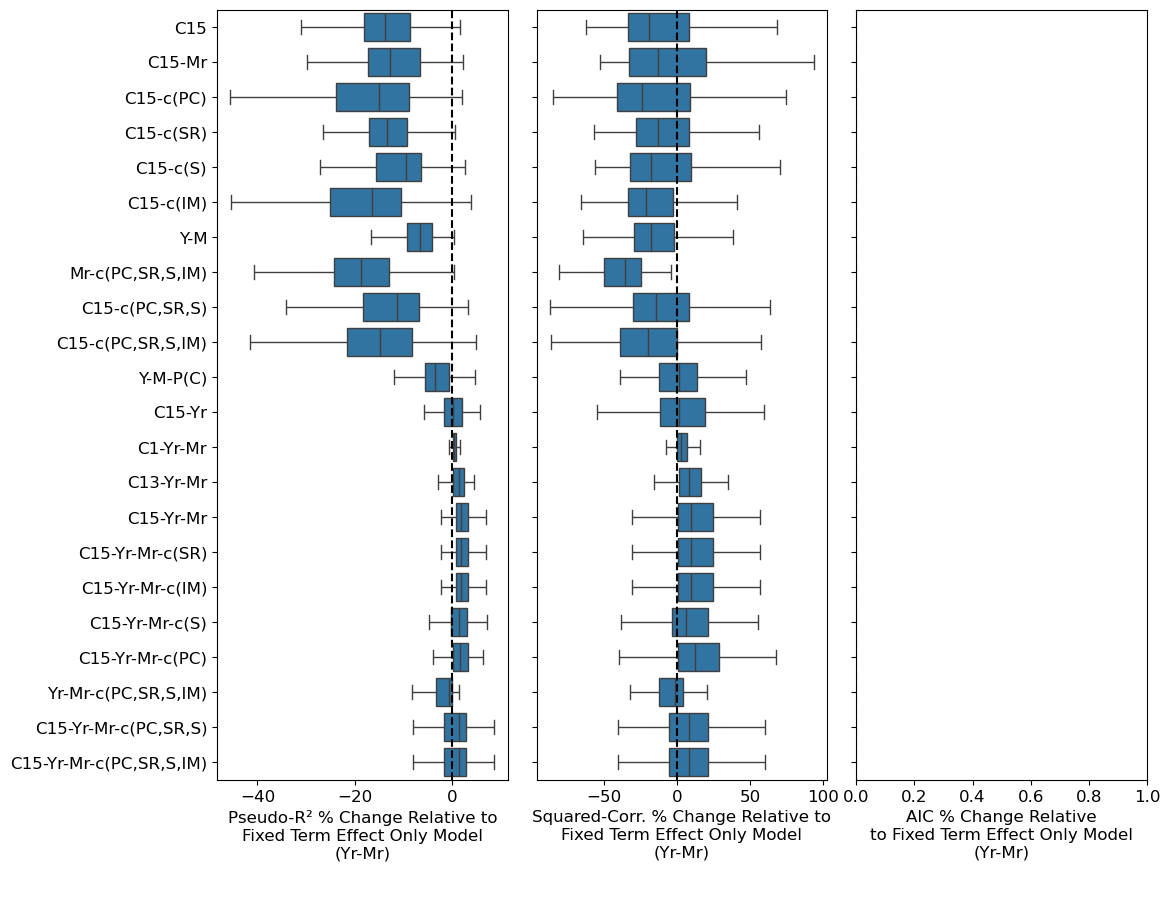

In [8]:
plt.rcParams.update({'font.size': 12})

df_rsq = df.copy().sort_values(['bootstrap_iteration', 'model_order']).reset_index(drop=True)
df_prsq = df.copy().sort_values(['bootstrap_iteration', 'model_order']).reset_index(drop=True)

baseline = df_rsq[df_rsq['model_name'] == 'Year|region + Month|region'] \
    .set_index(['bootstrap_iteration', 'region'])['r_squared']
df_rsq['r_squared_normed'] = df_rsq.apply(
    lambda row: 100 * (row['r_squared'] / baseline[(row['bootstrap_iteration'], row['region'])] - 1), axis=1
)
df_rsq = df_rsq[df_rsq['model_name'] != 'Year|region + Month|region']

baseline = df_prsq[df_prsq['model_name'] == 'Year|region + Month|region'] \
    .set_index(['bootstrap_iteration', 'region'])['pseudo_r_squared']
df_prsq['r_squared_normed'] = df_prsq.apply(
    lambda row: 100 * (row['pseudo_r_squared'] / baseline[(row['bootstrap_iteration'], row['region'])] - 1), axis=1
)
df_prsq = df_prsq[df_prsq['model_name'] != 'Year|region + Month|region']

df_prsq_out = df_prsq.copy()
df_rsq_out = df_rsq.copy()

df_prsq_out['stat'] = 'Out-Sample'
df_rsq_out['stat'] = 'Out-Sample'

fig, axarr = plt.subplots(1, 3, figsize=(12, 10), gridspec_kw={'wspace': 0.1}, sharey=True)

sns.boxplot(
    y='model_id', x='r_squared_normed', data=df_prsq, ax=axarr[0], 
    order=order, showfliers=False, legend=False
)
sns.boxplot(
    y='model_id', x='r_squared_normed', data=df_rsq, ax=axarr[1], 
    order=order, showfliers=False, legend=True
)

axarr[1].legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.12),
    frameon=False,
    fontsize=10,
    ncols=3
)


axarr[0].set_ylabel('')
axarr[0].set_xlabel('Pseudo-R² % Change Relative to\nFixed Term Effect Only Model\n(Yr-Mr)')
axarr[1].set_xlabel('Squared-Corr. % Change Relative to\nFixed Term Effect Only Model\n(Yr-Mr)')
axarr[2].set_xlabel('AIC % Change Relative\nto Fixed Term Effect Only Model\n(Yr-Mr)')

axarr[0].axvline(0, color='k', ls='--')
axarr[1].axvline(0, color='k', ls='--')
axarr[2].axvline(0, color='k', ls='--')

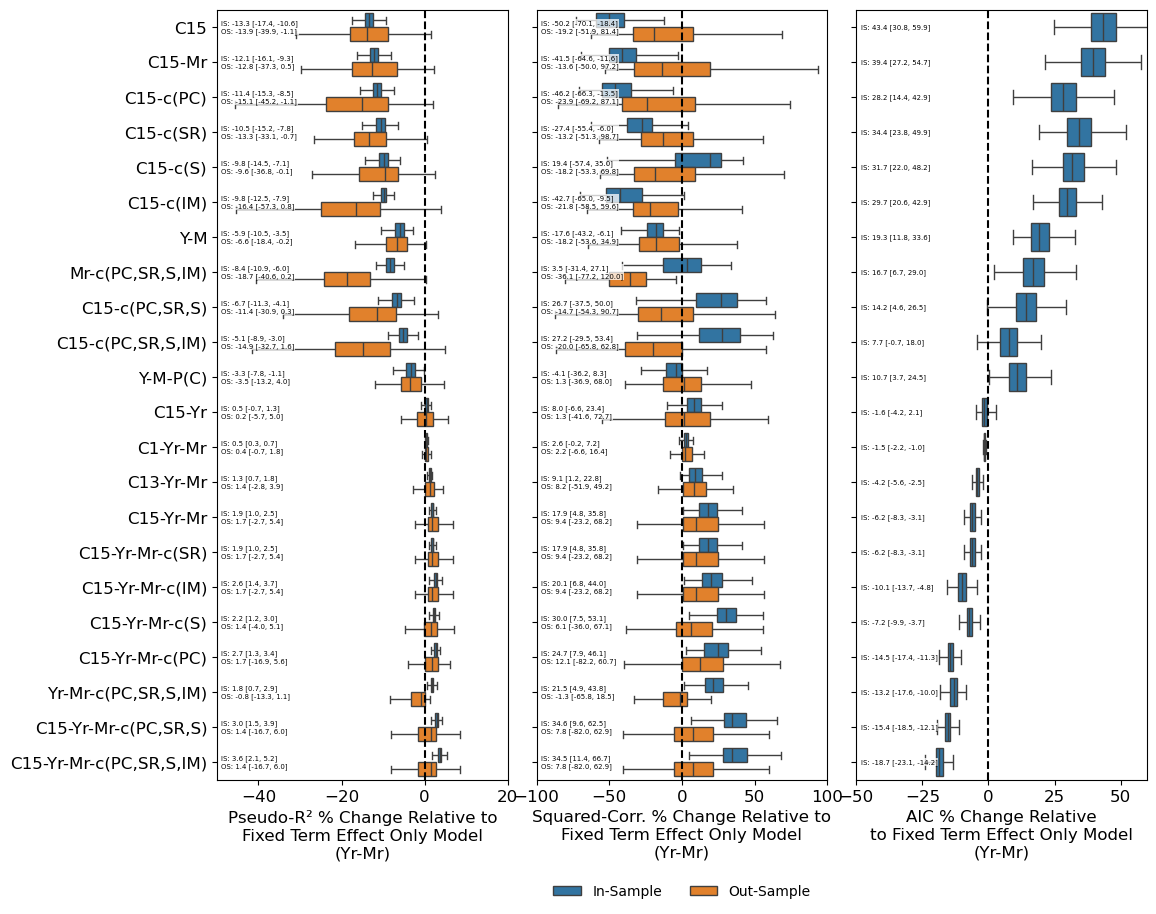

In [9]:
df_prsq = pd.concat([df_prsq_in, df_prsq_out]).reset_index(drop=True)
df_rsq = pd.concat([df_rsq_in, df_rsq_out]).reset_index(drop=True)
df_aic = df_aic_in.copy().reset_index(drop=True)

fig, axarr = plt.subplots(1, 3, figsize=(12, 10), gridspec_kw={'wspace': 0.1}, sharey=True)

sns.boxplot(
    y='model_id', x='r_squared_normed', data=df_prsq, ax=axarr[0], hue='stat',
    order=order, showfliers=False, legend=False
)
sns.boxplot(
    y='model_id', x='r_squared_normed', data=df_rsq, ax=axarr[1], hue='stat',
    order=order, showfliers=False, legend=True
)
sns.boxplot(
    y='model_id', x='aic_normed', data=df_aic, ax=axarr[2], hue='stat', 
    order=order, showfliers=False, legend=False
)

axarr[1].legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.12),
    frameon=False,
    fontsize=10,
    ncols=3
)


axarr[0].set_ylabel('')
axarr[0].set_xlabel('Pseudo-R² % Change Relative to\nFixed Term Effect Only Model\n(Yr-Mr)')
axarr[1].set_xlabel('Squared-Corr. % Change Relative to\nFixed Term Effect Only Model\n(Yr-Mr)')
axarr[2].set_xlabel('AIC % Change Relative\nto Fixed Term Effect Only Model\n(Yr-Mr)')

axarr[0].axvline(0, color='k', ls='--')
axarr[1].axvline(0, color='k', ls='--')
axarr[2].axvline(0, color='k', ls='--')

axarr[0].set_xlim([-50, 20])
axarr[1].set_xlim([-100, 100])
axarr[2].set_xlim([-50, 60])

# ---- Median [95% CI] text per model, for both In-Sample and Out-Sample ----
def annotate_median_ci(ax, data, value_col, model_order, x_frac=0.015):
    """One text block per model row, listing median [2.5, 97.5] for every
    `stat` group present (In-Sample / Out-Sample), placed at a fixed
    axes-fraction x position so it doesn't depend on seaborn's internal
    hue-dodge offsets."""
    stat_order = ['In-Sample', 'Out-Sample']
    for i, model in enumerate(model_order):
        lines = []
        for stat in stat_order:
            subset = data[(data['model_id'] == model) & (data['stat'] == stat)][value_col].dropna()
            if subset.empty:
                continue
            med, q025, q975 = subset.median(), subset.quantile(0.025), subset.quantile(0.975)
            tag = 'IS' if stat == 'In-Sample' else 'OS'
            lines.append(f"{tag}: {med:.1f} [{q025:.1f}, {q975:.1f}]")
        if lines:
            ax.text(x_frac, i, "\n".join(lines), transform=ax.get_yaxis_transform(),
                    fontsize=5, va='center', ha='left', color='k',
                    bbox=dict(facecolor='white', edgecolor='none', alpha=0.75, pad=0.5))


annotate_median_ci(axarr[0], df_prsq, 'r_squared_normed', order)
annotate_median_ci(axarr[1], df_rsq,  'r_squared_normed', order)
annotate_median_ci(axarr[2], df_aic,  'aic_normed',        order)

plt.savefig('img/figure_s11.png', dpi=300, bbox_inches='tight')